In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_streetlight_dataset (2).csv")

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

C:\Users\safda\AppData\Local\Temp\ipykernel_12628\966722803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [4]:
model1 = joblib.load("logistic.pkl")   # logistic
model2 = joblib.load("random.pkl")     # random


In [5]:
df['hour'] = df['timestamp'].dt.hour

X_model1 = df.drop(['fault_type','timestamp'], axis=1)

In [6]:
df['pred_logistic'] = model1.predict(X_model1)

In [7]:
df['pred_logistic'].value_counts()

pred_logistic
0    20702
1     5115
Name: count, dtype: int64

In [8]:
df['hour'] = df['timestamp'].dt.hour

X_model2 = df.drop(['fault_type','timestamp','pred_logistic'], axis=1)

In [9]:
df['pred_random'] = model2.predict(X_model2)

In [10]:
def calculate_mttd(data, pred_col):

    faults = data[data['fault_type']==1]['timestamp'].reset_index(drop=True)
    detects = data[data[pred_col]==1]['timestamp'].reset_index(drop=True)

    n = min(len(faults), len(detects))

    faults = faults[:n]
    detects = detects[:n]

    mttd = (detects - faults).dt.total_seconds().mean()

    return mttd

In [11]:
mttd_logistic = calculate_mttd(df,'pred_logistic')
mttd_random = calculate_mttd(df,'pred_random')

print("MTTD Model 1:", mttd_logistic)
print("MTTD Model 2:", mttd_random)


MTTD Model 1: -831.8329425556858
MTTD Model 2: 479.5973036342321


In [12]:
models = ['pred_logistic', 'pred_random']
mttd_values = [mttd_logistic, mttd_random]

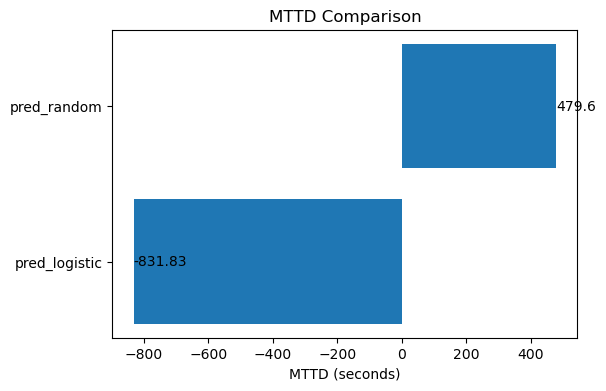

In [13]:
plt.figure(figsize=(6,4))

bars = plt.barh(models, mttd_values)

plt.xlabel("MTTD (seconds)")
plt.title("MTTD Comparison")

for bar in bars:
    width = bar.get_width()
    plt.text(width,
             bar.get_y() + bar.get_height()/2,
             round(width,2),
             va='center')

plt.show()

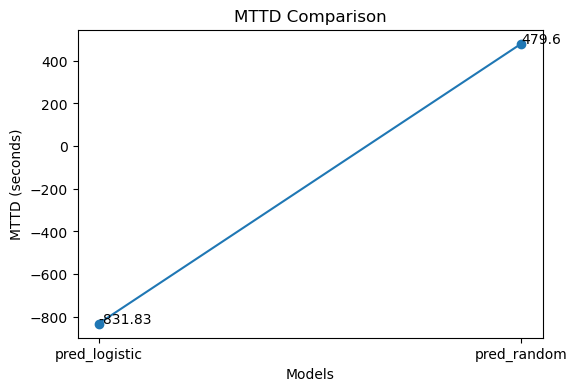

In [14]:
plt.figure(figsize=(6,4))

plt.plot(models, mttd_values, marker='o')

for i, value in enumerate(mttd_values):
    plt.text(models[i], value, round(value,2))

plt.title("MTTD Comparison")
plt.xlabel("Models")
plt.ylabel("MTTD (seconds)")

plt.show()

In [15]:
import pandas as pd

data = {'Model':['Logistic','RandomForest'],
        'MTTD':[mttd_logistic,mttd_random]}

df = pd.DataFrame(data)

df.to_csv("mttd_models1.csv",index=False)

In [16]:
pf_logistic = 2 * mttd_logistic
pf_rf = 2 * mttd_random

In [17]:
import pandas as pd

data = {
    "Model": ["Logistic Regression","Random Forest"],
    "MTTD": [mttd_logistic, mttd_random],
    "Polling Frequency": [pf_logistic, pf_rf]
}

df_pf = pd.DataFrame(data)

print(df_pf)

                 Model        MTTD  Polling Frequency
0  Logistic Regression -831.832943       -1663.665885
1        Random Forest  479.597304         959.194607


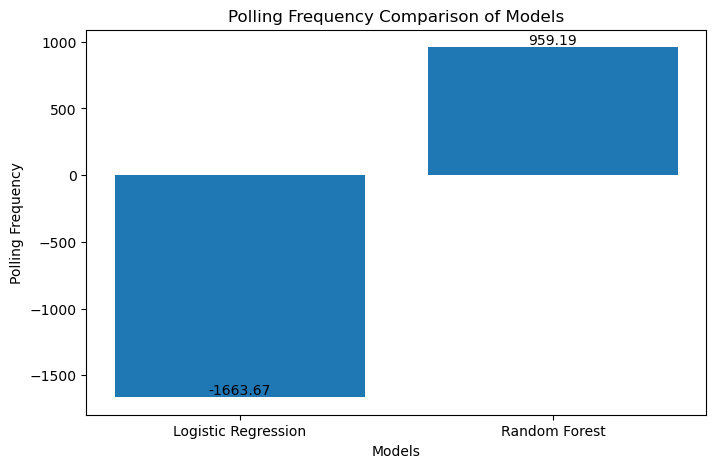

In [18]:
import matplotlib.pyplot as plt

models = ["Logistic Regression","Random Forest"]
pf_values = [pf_logistic, pf_rf]

plt.figure(figsize=(8,5))
bars = plt.bar(models, pf_values)

plt.xlabel("Models")
plt.ylabel("Polling Frequency")
plt.title("Polling Frequency Comparison of Models")

# show values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval,
             round(yval,2),
             ha='center',
             va='bottom')

plt.show()

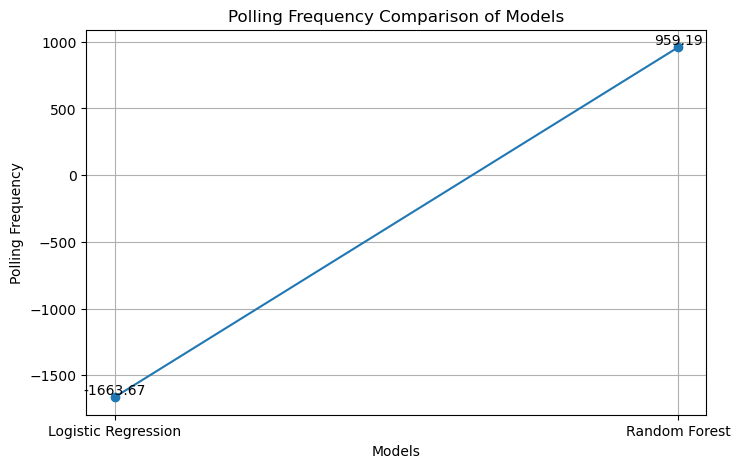

In [19]:
import matplotlib.pyplot as plt

models = ["Logistic Regression","Random Forest"]
pf_values = [pf_logistic, pf_rf]

plt.figure(figsize=(8,5))

plt.plot(models, pf_values, marker='o')

plt.xlabel("Models")
plt.ylabel("Polling Frequency")
plt.title("Polling Frequency Comparison of Models")

# show values on points
for i, value in enumerate(pf_values):
    plt.text(i, value, round(value,2), ha='center', va='bottom')

plt.grid(True)
plt.show()

In [20]:
import pandas as pd

data = {'Model':['Logistic','RandomForest'],
        'Polling Frequency':[pf_logistic, pf_rf]}

df = pd.DataFrame(data)

df.to_csv("pf_models1.csv",index=False)